<a href="https://colab.research.google.com/github/vaibhavkatex/The-Internship-2026/blob/main/bmw%20car%20prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import joblib

In [49]:
# Load the dataset
df = pd.read_csv("bmw.csv")
df.shape
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0


<Axes: xlabel='count', ylabel='model'>

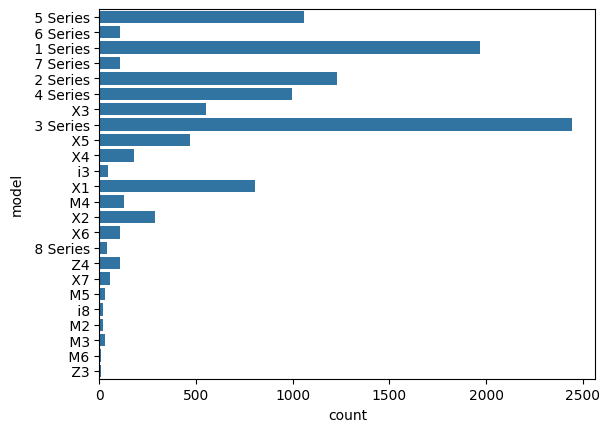

In [53]:
sns.countplot(df["model"])

In [46]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000
mean,2017.078935,22733.408867,25496.986550,131.702068,56.399035,2.167767
std,2.349038,11415.528189,25143.192559,61.510755,31.336958,0.552054
min,1996.000000,1200.000000,1.000000,0.000000,5.500000,0.000000
25%,2016.000000,14950.000000,5529.000000,135.000000,45.600000,2.000000
50%,2017.000000,20462.000000,18347.000000,145.000000,53.300000,2.000000
75%,2019.000000,27940.000000,38206.000000,145.000000,62.800000,2.000000
max,2020.000000,123456.000000,214000.000000,580.000000,470.800000,6.600000


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10781 non-null  object 
 1   year          10781 non-null  int64  
 2   price         10781 non-null  int64  
 3   transmission  10781 non-null  object 
 4   mileage       10781 non-null  int64  
 5   fuelType      10781 non-null  object 
 6   tax           10781 non-null  int64  
 7   mpg           10781 non-null  float64
 8   engineSize    10781 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 758.2+ KB


In [30]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0


In [31]:
X = df.drop("price", axis=1)
y = df["price"]

In [32]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,year,mileage,tax,mpg,engineSize,model_ 2 Series,model_ 3 Series,model_ 4 Series,model_ 5 Series,model_ 6 Series,...,model_ Z3,model_ Z4,model_ i3,model_ i8,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2014,67068,125,57.6,2.0,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,2018,14827,145,42.8,2.0,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
2,2016,62794,160,51.4,3.0,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,2017,26676,145,72.4,1.5,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2014,39554,160,50.4,3.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [33]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.33,
    random_state=42
)

In [35]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [36]:
print(model.intercept_)

22769.23322806014


In [37]:
print(model.coef_)

[ 4190.63322805 -2861.37968177  -582.75046271 -3510.65704241
  2005.5440842    -18.24610734  1119.00586434   763.97460933
  1369.94279727   535.7360215   1364.16241742  1976.40062567
   532.66520198   822.87527535  1653.02039761  1436.62161025
   334.35775507   644.74973399   611.21476111  1821.65372197
  1211.53978555  3391.29778383  1918.71112208  2787.33630457
   587.82047445   582.06157195  2904.87141245  1576.68091576
  -179.08577879   448.60447365   123.23864139  1554.06164006
   465.24535718  -240.91443616]


In [38]:
y_pred = model.predict(X_test)

In [39]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
8728,15300,16165.687525
761,15495,14858.075087
7209,39875,37661.955658
6685,21730,22674.767563
8548,13799,17070.498915
9385,24499,29031.029121
6085,42202,43761.180594
1885,32400,28531.607733
4921,28990,26919.132995
1121,15790,17545.684622


In [40]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.8674525584714494


In [41]:
joblib.dump(model, "BMW.pkl")

['BMW.pkl']

In [42]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [43]:
joblib.dump(df.drop("price", axis=1).columns.tolist(), "columns.pkl")

['columns.pkl']